## 1) Imports

In [79]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import warnings
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing

## 2) Config

In [109]:
TARGET = "hpi"  # "HPI_YoY"

EXOG_VARS = [
    # "FLOOD_FREQUENCY",
    # "FLOOD_PROPERTY_DAMAGE",
    # "FLOOD_DURATION_HOURS",
    # "HSI",
    # "DROUGHT_ANNUAL_MEAN_INDEX",
    # "FIRE_FREQUENCY",
    # "FIRE_SIZE",
    "yr",
    "hpi_change",
    # "index_nsa",
    # "state",
    # "cz_name",
    "flood_frequency",
    "flood_property_damage",
    "flood_duration_hours",
    "heat_stress_index",
    "drought_annual_mean_index",
    "fire_frequency",
    "fire_size",
    "deaths_hurricane",
    "injuries_hurricane",
    "damage_hurricane",
    "real_gdp",
    "unemployment_rate",
    "prop_rate",
    "total_home_purchase",
    "total_amt_purchase",
    "total_population",
]

STATIC_VARS = ["county_fips"]  # e.g. "population", "elevation", "urban_rural_code"

# FORECAST_YEARS = 10
SEQ_LEN = 5  # 10 YEAR WINDOW FOR LSTM

## 3. Exogenous forecasting function

In [95]:
def try_arima_or_hw(series, steps):
    """Try ARIMA; fallback to Holt-Winters if ARIMA fails."""
    series = pd.Series(series).astype(float)

    try:
        model = ARIMA(series, order=(1, 1, 1)).fit(method="powell", maxiter=10000)
        fc = model.forecast(steps)
        return np.array(fc)
    except:
        model = ExponentialSmoothing(series, trend="add").fit()
        fc = model.forecast(steps)
        return np.array(fc)

## 4) Function to Forecast all exogenous variables

In [96]:
def forecast_all_exogs(df, steps, static_variables_dict=None):
    future = {}

    for var in EXOG_VARS:
        # print(f"Forecasting exogenous variable: {var}")
        series = df[var].values
        future[var] = try_arima_or_hw(series, steps)

    if static_variables_dict:
        for var in STATIC_VARS:
            static_value = static_variables_dict[var]
            # future[var] = np.repeat(static_value, steps)
            # future = np.column_stack([future[var] for var in EXOG_VARS + (STATIC_VARS if static_variables_dict else [])])

            future_with_static = np.concatenate(
                future, np.repeat([static_value], steps, axis=0), axis=1
            )

    return pd.DataFrame(future_with_static if static_variables_dict else future)

## 5) Function to prepare multivariate LSTM dataset

In [98]:
def create_sequences(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i : i + seq_len])  # (seq_len, num_features)
        y.append(data[i + seq_len][0])  # next-step HPI_YoY
    return torch.tensor(X).float(), torch.tensor(y).float().unsqueeze(-1)

## 6) LSTM Model

In [99]:
class LSTMModel(nn.Module):
    def __init__(self, num_features, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(num_features, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]  # last timestep output
        return self.fc(out)

## 7) LSTM Training Function

In [123]:
def train_with_validation(
    df, epochs, add_county_fips=False, patience=20, checkpoint_path="best_lstm.pt"
):

    # ---------------------
    # STEP 1: Build dataset with HPI + exogs
    # ---------------------
    cols = EXOG_VARS + STATIC_VARS if add_county_fips else EXOG_VARS
    full_df = pd.concat([df[[TARGET] + cols]], ignore_index=True, axis=0)

    data = full_df.values

    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)

    # ---------------------
    # STEP 2: Create sequences
    # ---------------------
    X, y = create_sequences(data_scaled[: len(df)], SEQ_LEN)

    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    y = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)

    print("X has NaN:", np.isnan(X).any(), "Inf:", np.isinf(X).any())
    print("y has NaN:", np.isnan(y).any(), "Inf:", np.isinf(y).any())

    # ---------------------
    # STEP 3: Train/Val Split (80/20)
    # ---------------------
    train_size = int(0.8 * len(X))
    X_train, X_val = X[:train_size], X[train_size:]
    y_train, y_val = y[:train_size], y[train_size:]

    val_size = int(0.5 * len(X_val))
    X_test, X_val = X[:val_size], X[val_size:]
    y_test, y_val = y[:val_size], y[val_size:]

    # Convert to torch
    X_train = torch.tensor(X_train).float()
    y_train = torch.tensor(y_train).float()
    X_val = torch.tensor(X_val).float()
    y_val = torch.tensor(y_val).float()
    X_test = torch.tensor(X_test).float()
    y_test = torch.tensor(y_test).float()

    # ---------------------
    # STEP 4: Model + Loss + Optimizer
    # ---------------------
    model = LSTMModel(num_features=data.shape[1])
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.003)

    # For tracking
    train_losses = []
    val_losses = []

    # Early stopping
    best_val_loss = float("inf")
    patience_counter = 0

    # ---------------------
    # STEP 5: Training Loop
    # ---------------------
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        pred = model(X_train)
        loss = criterion(pred, y_train)
        loss.backward()
        optimizer.step()

        # ---- Validation ----
        model.eval()
        with torch.no_grad():
            val_pred = model(X_val)
            val_loss = criterion(val_pred, y_val)

        # Track losses
        train_losses.append(loss.item())
        val_losses.append(val_loss.item())

        # Print occasionally
        if (epoch + 1) % 100 == 0:
            print(
                f"Epoch {epoch+1}/{epochs} | Train Loss: {loss.item():.6f} | Val Loss: {val_loss.item():.6f}"
            )

        # ---- Early Stopping Check ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0

            # Save best checkpoint
            torch.save(model.state_dict(), checkpoint_path)
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

    print(f"Best validation loss: {best_val_loss:.6f}")

    # Load best weights
    model.load_state_dict(torch.load(checkpoint_path))

    # ---------------------
    # STEP 6: Test Set Evaluation (last 20% of df)
    # ---------------------
    y_test_pred = model(X_test).detach().numpy()

    # Inverse scaling
    def invert(values):
        pad = np.zeros(
            (len(values), len(EXOG_VARS) + (len(STATIC_VARS) if add_county_fips else 0))
        )
        return scaler.inverse_transform(np.concatenate([values, pad], axis=1))[:, 0]

    y_test_inv = invert(y_test.numpy())
    y_test_pred_inv = invert(y_test_pred)

    # ---------------------
    # STEP 7: Plot predictions
    # ---------------------
    plt.figure(figsize=(10, 5))
    plt.plot(y_test_inv, label="Actual")
    plt.plot(y_test_pred_inv, label="Predicted", linestyle="-")
    plt.title("LSTM Validation Prediction")
    plt.xlabel("Test Data Point Index")
    plt.ylabel(TARGET)
    plt.grid(True)
    plt.legend()
    plt.show()

    # ---------------------
    # STEP 8: Loss curves
    # ---------------------
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.title("Loss Curves")
    plt.xlabel("Epoch")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ------------------------
    # STEP 9: Accuracy metrics
    # ------------------------
    mae = mean_absolute_error(y_test_inv, y_test_pred_inv)
    rmse = np.sqrt(mean_squared_error(y_test_inv, y_test_pred_inv))
    r2 = r2_score(y_test_inv, y_test_pred_inv)

    mape = np.mean(np.abs((y_test_inv - y_test_pred_inv) / (y_test_inv + 1e-9))) * 100
    smape = 100 * np.mean(
        2
        * np.abs(y_test_inv - y_test_pred_inv)
        / (np.abs(y_test_inv) + np.abs(y_test_pred_inv) + 1e-9)
    )

    print("\nVALIDATION FORECAST ACCURACY")
    print("----------------------------")
    print(f"MAE:   {mae:.4f}")
    print(f"RMSE:  {rmse:.4f}")
    print(f"R²:    {r2:.4f}")
    print(f"MAPE:  {mape:.2f}%")
    print(f"SMAPE: {smape:.2f}%")

    return model, (train_losses, val_losses)

## 8) Function to Forecast Exogenous Variables

In [101]:
def forecast(model, base_exog_df, no_of_years, static_variables_dict=None):

    # -------------------------------------------
    # STEP 1: Forecast exogenous variables
    # -------------------------------------------
    future_exog_df = forecast_all_exogs(
        base_exog_df, no_of_years, static_variables_dict
    )

    exog_cols = list(future_exog_df.columns)

    # -------------------------------------------
    # STEP 2: Scale exogenous variables
    # -------------------------------------------
    exog_scaler = MinMaxScaler()
    base_exogs_scaled = exog_scaler.fit_transform(base_exog_df[exog_cols])
    future_exogs_scaled = exog_scaler.transform(future_exog_df[exog_cols])

    # -------------------------------------------
    # STEP 3: Scale target separately (fit on actual HPI history)
    # -------------------------------------------
    target_scaler = MinMaxScaler()
    target_series = base_exog_df[TARGET].values.reshape(-1, 1)
    target_scaler.fit(target_series)

    # Initialize the window from the end of training
    history = np.concatenate(
        [target_scaler.transform(target_series), base_exogs_scaled], axis=1
    )

    window = torch.tensor(history[-SEQ_LEN:], dtype=torch.float32).unsqueeze(0)

    future_preds_scaled = []

    # -------------------------------------------
    # STEP 4: Autoregressive Forecast Loop
    # -------------------------------------------
    for i in range(no_of_years):

        # model outputs scaled prediction
        output = model(window)
        pred_scaled = output.detach().numpy()[0, 0]
        future_preds_scaled.append(pred_scaled)

        # get scaled exogs for current step
        next_exogs_scaled = future_exogs_scaled[i]

        # build next row (scaled target + scaled exogs)
        next_row = np.concatenate([[pred_scaled], next_exogs_scaled])
        next_row = torch.tensor(next_row, dtype=torch.float32).reshape(1, 1, -1)

        # slide window
        window = torch.cat((window[:, 1:, :], next_row), dim=1)

    # -------------------------------------------
    # STEP 5: Invert scaling on predictions
    # -------------------------------------------
    future_preds = target_scaler.inverse_transform(
        np.array(future_preds_scaled).reshape(-1, 1)
    ).flatten()

    return future_preds, future_exog_df

## 9) Run Pipeline

In [ ]:
climate_hpi = pd.read_csv(
    "/Users/leonard/Library/CloudStorage/Dropbox/Duke/Academics/Year 2 Semester 1/Capstone/Code/Capstone_Citizensbank_climate-risk_insurance-exposure_monitoring/02_processed_data/FINAL_CLIMATE_FINANCIAL_DATA.csv"
)
# pd.read_csv(
#     "../../02_processed_data/wildfire_drought_hpi_flood_heat_huricane.csv"
# )
climate_hpi = climate_hpi.rename(
    columns={
        "index_nsa": "hpi"
    }  # {"hpi_yoy": "HPI_YoY", "county_fips5": "county_fips"}
)
climate_hpi["real_gdp"] = pd.to_numeric(climate_hpi["real_gdp"], errors="coerce")
climate_hpi

,Unnamed: 0,county_fips5,yr,hpi_change,hpi,state,cz_name,flood_frequency,flood_property_damage,flood_duration_hours,...,deaths_hurricane,injuries_hurricane,damage_hurricane,real_gdp,unemployment_rate,prop_rate,county_fips,total_home_purchase,total_amt_purchase,total_population
0,14,1001,2000,2.50,141.23,ALABAMA,AUTAUGA,1.0,200000.0,3.50,...,0.0,0.0,0.0,0.0,4.1,0.000,1001.0,831.0,72778000.0,44021.0
1,15,1001,2001,3.44,146.08,ALABAMA,AUTAUGA,2.0,37000.0,4.25,...,0.0,0.0,0.0,1041239.0,4.1,0.000,1001.0,766.0,71592000.0,44889.0
2,16,1001,2002,2.67,149.98,ALABAMA,AUTAUGA,0.0,0.0,0.00,...,0.0,0.0,0.0,1080135.0,4.8,0.000,1001.0,730.0,78607000.0,45909.0
3,17,1001,2003,1.79,152.66,ALABAMA,AUTAUGA,2.0,58000.0,6.00,...,0.0,0.0,0.0,1111465.0,5.0,0.245,1001.0,835.0,93128000.0,46800.0
4,18,1001,2004,2.92,157.12,ALABAMA,AUTAUGA,1.0,8000.0,3.50,...,0.0,0.0,0.0,1283522.0,4.7,0.245,1001.0,908.0,111256000.0,48366.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57236,103285,56045,2016,1.50,207.30,WYOMING,WESTON,0.0,0.0,0.00,...,0.0,0.0,0.0,284675.0,5.0,0.000,56045.0,25.0,3524000.0,7228.0
57237,103286,56045,2017,0.99,209.35,WYOMING,WESTON,0.0,0.0,0.00,...,0.0,0.0,0.0,285172.0,4.1,0.000,56045.0,70.0,10758000.0,6962.0
57238,103287,56045,2018,-1.00,207.26,WYOMING,WESTON,1.0,0.0,40.08,...,0.0,0.0,0.0,294224.0,3.5,0.000,56045.0,44.0,6840000.0,6895.0
57239,103288,56045,2019,8.55,224.99,WYOMING,WESTON,4.0,35000.0,28.75,...,0.0,0.0,0.0,303539.0,3.0,0.000,56045.0,51.0,10475000.0,6880.0


### Train

X has NaN: False Inf: False
y has NaN: False Inf: False
Epoch 100/4000 | Train Loss: 0.000661 | Val Loss: 0.000522
Epoch 200/4000 | Train Loss: 0.000328 | Val Loss: 0.000281
Epoch 300/4000 | Train Loss: 0.000213 | Val Loss: 0.000191
Epoch 400/4000 | Train Loss: 0.000180 | Val Loss: 0.000164
Epoch 500/4000 | Train Loss: 0.000261 | Val Loss: 0.000164
Epoch 600/4000 | Train Loss: 0.000144 | Val Loss: 0.000129
Epoch 700/4000 | Train Loss: 0.000134 | Val Loss: 0.000123
Epoch 800/4000 | Train Loss: 0.000122 | Val Loss: 0.000109
Epoch 900/4000 | Train Loss: 0.000117 | Val Loss: 0.000105
Epoch 1000/4000 | Train Loss: 0.000110 | Val Loss: 0.000099
Epoch 1100/4000 | Train Loss: 0.000107 | Val Loss: 0.000095
Epoch 1200/4000 | Train Loss: 0.000104 | Val Loss: 0.000092
Epoch 1300/4000 | Train Loss: 0.000116 | Val Loss: 0.000112
Epoch 1400/4000 | Train Loss: 0.000101 | Val Loss: 0.000095
Epoch 1500/4000 | Train Loss: 0.000095 | Val Loss: 0.000086
Epoch 1600/4000 | Train Loss: 0.000103 | Val Loss: 0.

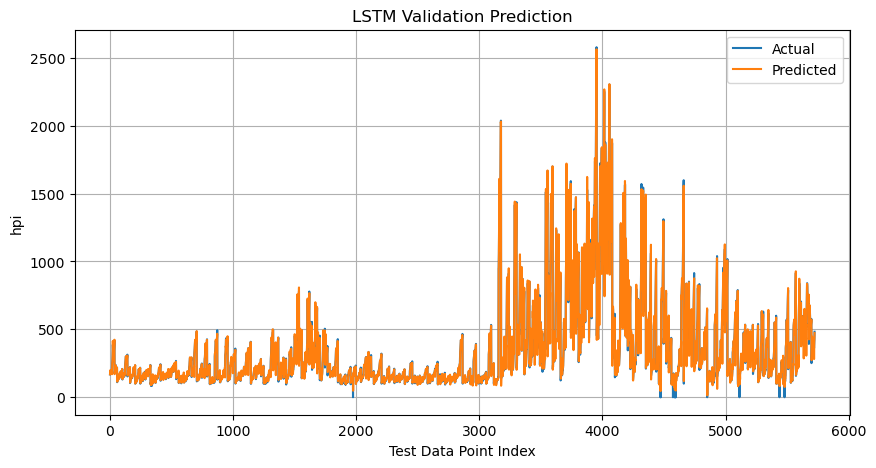

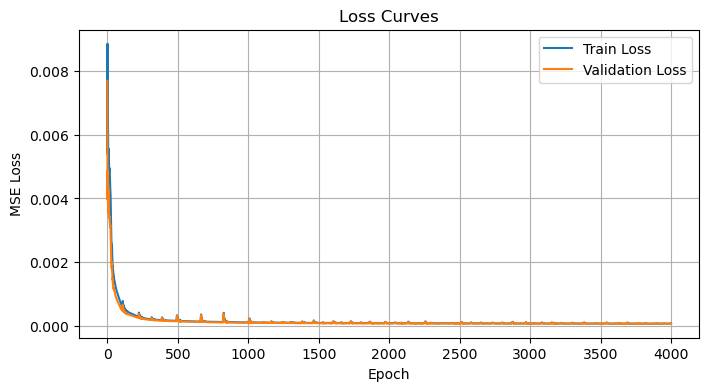


VALIDATION FORECAST ACCURACY
----------------------------
MAE:   12.4716
RMSE:  28.7778
R²:    0.9923
MAPE:  27470440337.60%
SMAPE: 5.01%


In [124]:
model, train_val_loss = train_with_validation(climate_hpi, 4000, False, 150)

### Forecast

In [ ]:
NO_OF_YEARS = 4


def forecast_county(df_county):
    future_hpi, future_exogs = forecast(model, df_county, NO_OF_YEARS, None)
    # future_hpi, future_exogs = forecast_new(model, scalar, df_county, NO_OF_YEARS)

    years = list(
        range(df_county["yr"].max() + 1, df_county["yr"].max() + 1 + NO_OF_YEARS)
    )

    result = pd.DataFrame(
        {
            "yr": years,
            "county_fips": df_county["county_fips"].iloc[0],
            TARGET: future_hpi.flatten(),
        }
    )

    result = pd.concat([result, future_exogs], axis=1)
    return result

In [126]:
all_results = []

for fips in climate_hpi["county_fips"].unique()[0:10]:
    df_county = climate_hpi[climate_hpi["county_fips"] == fips].sort_values("yr")
    res = forecast_county(df_county)
    all_results.append(res)

all_results = pd.concat(all_results, ignore_index=True)
print("\nForecast Results for Multiple Counties:\n")
all_results


Forecast Results for Multiple Counties:



,yr,county_fips,hpi,yr,hpi_change,flood_frequency,flood_property_damage,flood_duration_hours,heat_stress_index,drought_annual_mean_index,...,fire_size,deaths_hurricane,injuries_hurricane,damage_hurricane,real_gdp,unemployment_rate,prop_rate,total_home_purchase,total_amt_purchase,total_population
0,2021,1001.0,119.171486,2021.0,0.631845,0.652381,-71225.962284,4.541509,0.429319,0.367000,...,76.733993,0.000000,0.0,0.000000e+00,1.859918e+06,5.360005,-6.561143e-06,1253.437281,2.679945e+08,61753.523306
1,2022,1001.0,131.884888,2022.0,0.540899,0.599134,-104063.562331,4.191820,0.430420,0.414389,...,76.533934,0.000000,0.0,0.000000e+00,1.891012e+06,5.420011,-1.312229e-05,1442.276079,3.154382e+08,64663.411380
2,2023,1001.0,139.266357,2023.0,0.449952,0.545887,-136901.162378,3.842131,0.431520,0.461779,...,76.333875,0.000000,0.0,0.000000e+00,1.922107e+06,5.480016,-1.968343e-05,1631.114876,3.628818e+08,67573.299455
3,2024,1001.0,141.794693,2024.0,0.359005,0.492640,-169738.762424,3.492441,0.432621,0.509168,...,76.133817,0.000000,0.0,0.000000e+00,1.953201e+06,5.540021,-2.624457e-05,1819.953674,4.103255e+08,70483.187530
4,2021,1003.0,223.482025,2021.0,4.403474,6.809523,157542.998066,20.217761,0.378974,0.270097,...,1799.218682,0.380962,0.0,1.055816e+08,8.521118e+06,6.220001,2.904883e-05,5544.713880,1.433528e+09,242873.420128
5,2022,1003.0,233.581070,2022.0,4.426948,6.991341,153580.525444,20.674527,0.376431,0.344434,...,1830.794923,0.406934,0.0,1.320759e+08,8.810756e+06,6.340002,5.809251e-05,6035.002900,1.610341e+09,252519.607601
6,2023,1003.0,220.313980,2023.0,4.450423,7.173160,149618.052821,21.131294,0.373887,0.418772,...,1862.371164,0.432906,0.0,1.585702e+08,9.100394e+06,6.460002,8.713619e-05,6525.291919,1.787154e+09,262165.795074
7,2024,1003.0,225.915894,2024.0,4.473897,7.354978,145655.580199,21.588060,0.371343,0.493110,...,1893.947406,0.458878,0.0,1.850645e+08,9.390031e+06,6.580003,1.161799e-04,7015.580939,1.963967e+09,271811.982547
8,2021,1005.0,189.219131,2021.0,-0.764905,0.576190,108.516275,3.415017,0.427588,0.544728,...,135.433462,0.000000,0.0,0.000000e+00,7.545217e+05,7.805004,6.912901e-06,121.307273,2.144143e+07,24759.816562
9,2022,1005.0,148.175369,2022.0,-0.964918,0.585281,-318.036290,3.591621,0.429524,0.616803,...,123.517068,0.000000,0.0,0.000000e+00,7.526866e+05,7.910007,1.382509e-05,127.830804,2.306015e+07,24553.527224


### Cross-check

In [ ]:
hpi = pd.read_csv("../../02_processed_data/hpi_county_2000_2024.csv")
hpi = hpi[hpi["yr"].between(2021, 2025)]
hpi = hpi.rename(
    columns={"county_fips5": "county_fips", "county/county_equivalent": "county_name"}
)
hpi.sort_values(by=["county_fips", "yr"])

,state_name,county_name,county_fips,yr,hpi_change,index_nsa
35,AL,Autauga,1001,2021,8.04,207.76
36,AL,Autauga,1001,2022,14.03,236.89
37,AL,Autauga,1001,2023,9.35,259.05
38,AL,Autauga,1001,2024,8.20,280.30
83,AL,Baldwin,1003,2021,13.41,474.46
...,...,...,...,...,...,...
103264,WY,Washakie,56043,2024,1.88,401.40
103290,WY,Weston,56045,2021,4.97,246.69
103291,WY,Weston,56045,2022,6.15,261.87
103292,WY,Weston,56045,2023,1.32,265.32


In [165]:
all_results["yr"] = all_results["yr"].astype(int)
all_results = all_results.loc[:, ~all_results.columns.duplicated()]

In [ ]:
hpi_pred_actual = all_results.merge(hpi, "inner", ["yr", "county_fips"])
hpi_pred_actual["county_fips"] = hpi_pred_actual["county_fips"].astype(int)
hpi_pred_actual = hpi_pred_actual.rename(
    columns={
        "county_fips": "county",
        "yr": "year",
        "index_nsa": "actual",
        "hpi": "predicted",
    }
)
hpi_pred_actual = hpi_pred_actual[
    hpi_pred_actual["county"].isin([1001, 1003, 1005, 1007, 1009, 1011])
]  # , 1013, 1015, 1017, 1019
hpi_pred_actual[["county_name", "year", "actual", "predicted"]]

,county_name,year,actual,predicted
0,Autauga,2021,207.76,119.171486
1,Autauga,2022,236.89,131.884888
2,Autauga,2023,259.05,139.266357
3,Autauga,2024,280.30,141.794693
4,Baldwin,2021,474.46,223.482025
5,Baldwin,2022,556.96,233.581070
6,Baldwin,2023,622.63,220.313980
7,Baldwin,2024,638.45,225.915894
8,Barbour,2021,239.23,189.219131
9,Barbour,2022,271.15,148.175369


In [ ]:
df_long = hpi_pred_actual.melt(
    id_vars=["county_name", "year"],
    value_vars=["actual", "predicted"],
    var_name="series",
    value_name="value",
)

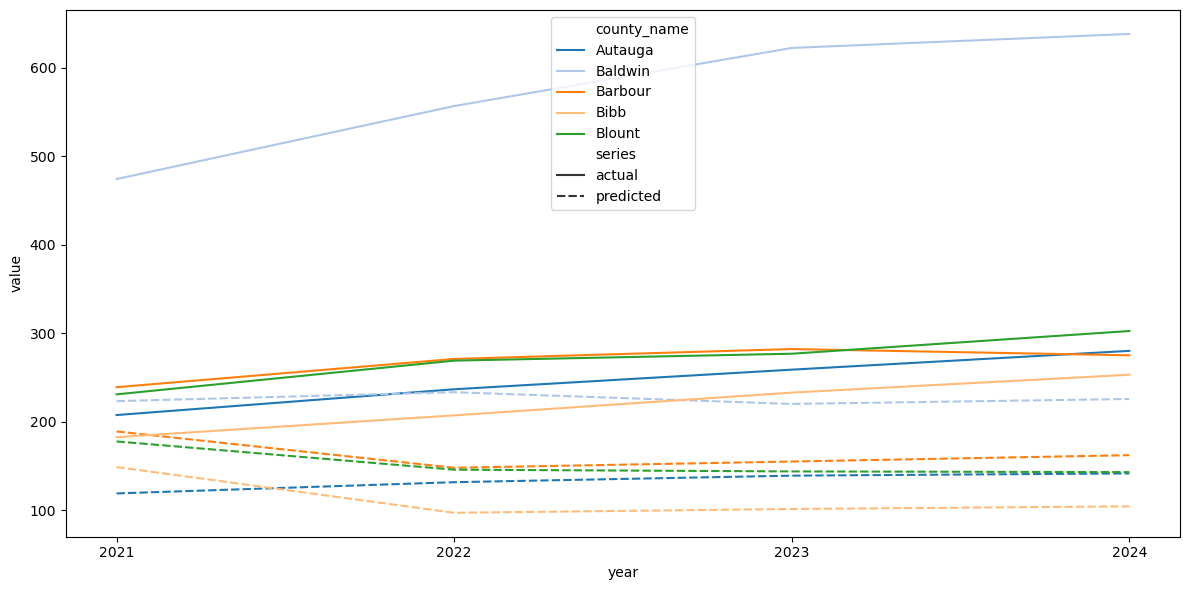

In [ ]:
import seaborn as sns
import matplotlib.ticker as mticker

plt.figure(figsize=(12, 6))

palette = sns.color_palette("tab20", n_colors=df_long["county_name"].nunique())

sns.lineplot(
    data=df_long,
    x="year",
    y="value",
    hue="county_name",
    style="series",
    palette=palette,
)

ax = plt.gca()
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))

plt.tight_layout()
plt.show()